In [ ]:
import pandas as pd

df = pd.read_csv('/content/HR_comma_sep.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

print("\nDescriptive statistics of the DataFrame:")
print(df.describe())

print("\nMissing values in each column:")
print(df.isnull().sum())

First 5 rows of the DataFrame:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   sala

In [ ]:
print("Correlation of numerical variables with 'left' column:")
print(df.corr()['left'].sort_values(ascending=False))

print("\nRetention rates by Department (proportion of employees who left):")
print(df.groupby('Department')['left'].mean().sort_values(ascending=False))

print("\nRetention rates by Salary (proportion of employees who left):")
print(df.groupby('salary')['left'].mean().sort_values(ascending=False))

Correlation of numerical variables with 'left' column:


ValueError: could not convert string to float: 'sales'

In [ ]:
print("Correlation of numerical variables with 'left' column:")
print(df.corr(numeric_only=True)['left'].sort_values(ascending=False))

print("\nRetention rates by Department (proportion of employees who left):")
print(df.groupby('Department')['left'].mean().sort_values(ascending=False))

print("\nRetention rates by Salary (proportion of employees who left):")
print(df.groupby('salary')['left'].mean().sort_values(ascending=False))

Correlation of numerical variables with 'left' column:
left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64

Retention rates by Department (proportion of employees who left):
Department
hr             0.290934
accounting     0.265971
technical      0.256250
support        0.248991
sales          0.244928
marketing      0.236597
IT             0.222494
product_mng    0.219512
RandD          0.153748
management     0.144444
Name: left, dtype: float64

Retention rates by Salary (proportion of employees who left):
salary
low       0.296884
medium    0.204313
high      0.066289
Name: left, dtype: float64


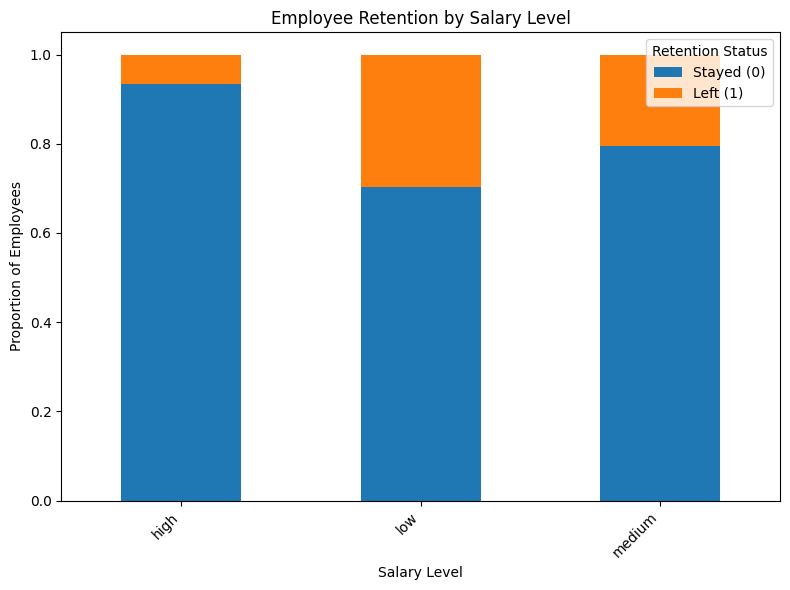

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the proportion of employees who left and stayed for each salary level
salary_retention = pd.crosstab(df['salary'], df['left'], normalize='index')

# Create the stacked bar chart
salary_retention.plot(kind='bar', stacked=True, figsize=(8, 6))

# Set chart title and labels
plt.title('Employee Retention by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Proportion of Employees')

# Customize legend
plt.legend(title='Retention Status', labels=['Stayed (0)', 'Left (1)'])

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

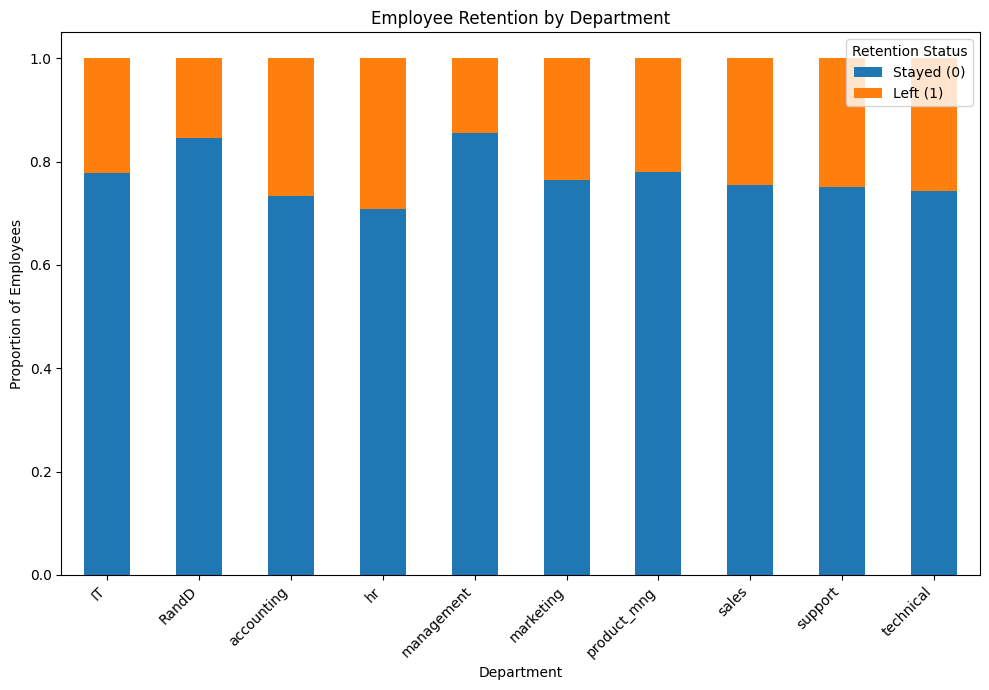

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the proportion of employees who left and stayed for each department
department_retention = pd.crosstab(df['Department'], df['left'], normalize='index')

# Create the stacked bar chart
department_retention.plot(kind='bar', stacked=True, figsize=(10, 7))

# Set chart title and labels
plt.title('Employee Retention by Department')
plt.xlabel('Department')
plt.ylabel('Proportion of Employees')

# Customize legend
plt.legend(title='Retention Status', labels=['Stayed (0)', 'Left (1)'])

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Identify categorical columns for one-hot encoding
categorical_cols = ['Department', 'salary']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define feature matrix X and target vector y
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of X_train (features):")
print(X_train.head())

print("\nFirst 5 rows of y_train (target):")
print(y_train.head())

Shape of X_train: (10499, 18)
Shape of X_test: (4500, 18)
Shape of y_train: (10499,)
Shape of y_test: (4500,)

First 5 rows of X_train (features):
       satisfaction_level  last_evaluation  number_project  \
12602                0.10             0.84               7   
4889                 0.57             0.68               4   
1572                 0.39             0.48               2   
13375                0.91             0.68               4   
879                  0.82             0.97               5   

       average_montly_hours  time_spend_company  Work_accident  \
12602                   250                   4              0   
4889                    154                   3              1   
1572                    154                   3              0   
13375                   132                   4              0   
879                     263                   5              0   

       promotion_last_5years  Department_RandD  Department_accounting  \
12602     

In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
# Using 'liblinear' solver for small datasets and 'lbfgs' for larger ones, with increased max_iter for convergence.
# 'liblinear' is good for small datasets and handles L1/L2 regularization.
model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Calculate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7831

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      3428
           1       0.58      0.33      0.42      1072

    accuracy                           0.78      4500
   macro avg       0.70      0.63      0.64      4500
weighted avg       0.76      0.78      0.76      4500

